# Phase 4: Modeling, Tuning & Submission

**Author:** Taline Zeidan  
**Course:** COE 546 — Machine Learning, Spring 2026  
**Input:** `data/train_features.csv`, `data/test_features.csv`  
**Output:** `outputs/submission.csv`

---

## Objectives

1. Train a **baseline LightGBM** to establish a benchmark AUC
2. Use **Optuna** (Bayesian hyperparameter optimization) to tune LightGBM, XGBoost, and CatBoost
3. **Ensemble** the three tuned models via weighted average (weights = CV AUC scores)
4. Generate a **submission CSV** with predicted probabilities for all test rows

---

## Design Decisions

| Decision | Choice | Reason |
|---|---|---|
| Model family | LightGBM + XGBoost + CatBoost | Tree ensembles dominate tabular competitions; each has different inductive biases — averaging reduces variance |
| Class imbalance | `scale_pos_weight=33.4` (LGB/XGB), `class_weights` (CatBoost) | 97.1% / 2.9% split; without correction the model predicts 0 for everything |
| Hyperparameter search | Optuna (Bayesian optimization, 100/100/50 trials) | More efficient than grid search; finds better parameters in fewer evaluations |
| Early stopping | Yes, 50 rounds | Prevents overfitting, speeds up each Optuna trial significantly |
| Validation | 5-fold Stratified CV | Stratified ensures each fold preserves the ~3% positive rate |
| Ensemble weighting | Weighted by CV AUC, normalized to sum=1 | Models with higher CV AUC contribute more to final prediction |
| Evaluation metric | ROC AUC | Competition metric — measures ranking quality across all thresholds |

## 1. Imports & Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ── ML Libraries ───────────────────────────────────────────────────────────
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial output

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# ── Paths ───────────────────────────────────────────────────────────────────
BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR  = os.path.join(BASE_DIR, 'data')
OUT_DIR   = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUT_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, 'train_features.csv')
TEST_PATH  = os.path.join(DATA_DIR, 'test_features.csv')
SUB_PATH   = os.path.join(OUT_DIR,  'submission.csv')

# ── Constants ───────────────────────────────────────────────────────────────
SEED            = 42
N_FOLDS         = 5
SCALE_POS_WEIGHT = 33.4   # 288592 / 8644 — ratio of negative to positive class
N_TRIALS_LGB    = 100
N_TRIALS_XGB    = 100
N_TRIALS_CB     = 50
EARLY_STOPPING  = 50

print('All imports successful.')
print(f'LightGBM : {lgb.__version__}')
print(f'XGBoost  : {xgb.__version__}')
print(f'CatBoost : {cb.__version__}')
print(f'Optuna   : {optuna.__version__}')

All imports successful.
LightGBM : 4.3.0
XGBoost  : 2.0.3
CatBoost : 1.2.10
Optuna   : 4.8.0


## 2. Load Data

In [2]:
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

FEATURE_COLS = [c for c in train.columns if c not in ['id', 'order_placed']]

X      = train[FEATURE_COLS]
y      = train['order_placed']
X_test = test[FEATURE_COLS]

print(f'Train : {X.shape}  |  Positives: {y.sum():,} ({y.mean()*100:.1f}%)')
print(f'Test  : {X_test.shape}')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Train : (297236, 29)  |  Positives: 8,644 (2.9%)
Test  : (99639, 29)
Features (29): ['timezone', 'action_type', 'promos_declined', 'customer_type', 'items_in_cart', 'cart_value', 'promo_type', 'discount_value', 'promos_shown', 'screen_size', 'promo_response', 'session_duration_s', 'inactivity_gap_s', 'hour_of_day', 'day_of_week', 'is_weekend', 'has_promo', 'engagement_ratio', 'active_time_s', 'promo_accepted', 'is_promo_type_S', 'discount_attractiveness', 'cart_qualifies_for_promo', 'is_returning_customer', 'is_high_activity_session', 'returning_x_promo_accepted', 'returning_x_session_duration', 'items_x_duration', 'promo_engagement_score']


## 3. Cross-Validation Helper

We define a reusable CV function that:
- Runs 5-fold stratified CV
- Returns out-of-fold (OOF) predictions for the full training set
- Returns averaged test predictions across all folds
- Reports per-fold and mean AUC

In [3]:
def run_cv(model_fn, X, y, X_test, n_folds=N_FOLDS, seed=SEED, label='Model'):
    """
    Run stratified K-fold CV.
    model_fn: callable that takes (X_tr, y_tr, X_val, y_val) and returns
              (oof_preds, test_preds) as 1D arrays.
    Returns: oof_preds (len=len(X)), test_preds (len=len(X_test)), mean_auc, std_auc
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    oof_preds   = np.zeros(len(X))
    test_preds  = np.zeros(len(X_test))
    fold_aucs   = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        oof_fold, test_fold = model_fn(X_tr, y_tr, X_val, y_val)

        oof_preds[val_idx] = oof_fold
        test_preds        += test_fold / n_folds

        fold_auc = roc_auc_score(y_val, oof_fold)
        fold_aucs.append(fold_auc)
        print(f'  [{label}] Fold {fold}/{n_folds} — AUC: {fold_auc:.5f}')

    mean_auc = np.mean(fold_aucs)
    std_auc  = np.std(fold_aucs)
    oof_auc  = roc_auc_score(y, oof_preds)
    print(f'  [{label}] OOF AUC: {oof_auc:.5f} | Mean: {mean_auc:.5f} ± {std_auc:.5f}')
    return oof_preds, test_preds, mean_auc, std_auc

print('CV helper defined.')

CV helper defined.


## 4. Baseline LightGBM

We first train a LightGBM model with sensible default parameters — no tuning. This gives us a **benchmark AUC** to compare against after Optuna tuning.

In [4]:
def lgb_baseline_fn(X_tr, y_tr, X_val, y_val):
    model = lgb.LGBMClassifier(
        n_estimators      = 1000,
        learning_rate     = 0.05,
        num_leaves        = 63,
        scale_pos_weight  = SCALE_POS_WEIGHT,
        n_jobs            = -1,
        random_state      = SEED,
        verbose           = -1,
    )
    model.fit(
        X_tr, y_tr,
        eval_set              = [(X_val, y_val)],
        callbacks             = [lgb.early_stopping(EARLY_STOPPING, verbose=False),
                                 lgb.log_evaluation(-1)]
    )
    oof  = model.predict_proba(X_val)[:, 1]
    test = model.predict_proba(X_test)[:, 1]
    return oof, test

print('Running baseline LightGBM (5-fold CV)...')
oof_lgb_base, test_lgb_base, auc_lgb_base, _ = run_cv(
    lgb_baseline_fn, X, y, X_test, label='LGB-Baseline'
)
print(f'\n✅ Baseline LightGBM CV AUC: {auc_lgb_base:.5f}')

Running baseline LightGBM (5-fold CV)...
  [LGB-Baseline] Fold 1/5 — AUC: 0.96057
  [LGB-Baseline] Fold 2/5 — AUC: 0.96247
  [LGB-Baseline] Fold 3/5 — AUC: 0.96074
  [LGB-Baseline] Fold 4/5 — AUC: 0.96112
  [LGB-Baseline] Fold 5/5 — AUC: 0.96303
  [LGB-Baseline] OOF AUC: 0.96138 | Mean: 0.96158 ± 0.00098

✅ Baseline LightGBM CV AUC: 0.96158


## 5. Optuna Tuning — LightGBM

Optuna uses **Bayesian optimization** (Tree-structured Parzen Estimator) to intelligently search the hyperparameter space. Unlike grid search which tries all combinations, Optuna learns from previous trials to focus on promising regions.

We search over: `num_leaves`, `learning_rate`, `min_child_samples`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`, `n_estimators`.

In [5]:
def lgb_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 300),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.0, 5.0),
        'scale_pos_weight' : SCALE_POS_WEIGHT,
        'n_jobs'           : -1,
        'random_state'     : SEED,
        'verbose'          : -1,
    }
    skf    = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    aucs   = []
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set  = [(X_val, y_val)],
            callbacks = [lgb.early_stopping(EARLY_STOPPING, verbose=False),
                         lgb.log_evaluation(-1)]
        )
        preds = model.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, preds))
    return np.mean(aucs)

print(f'Running Optuna on LightGBM ({N_TRIALS_LGB} trials × 3-fold)...')
study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS_LGB, show_progress_bar=True)

best_lgb_params = study_lgb.best_params
best_lgb_params.update({'scale_pos_weight': SCALE_POS_WEIGHT, 'n_jobs': -1,
                         'random_state': SEED, 'verbose': -1})
print(f'\n✅ Best LightGBM params: {best_lgb_params}')
print(f'   Best trial AUC: {study_lgb.best_value:.5f}')

Running Optuna on LightGBM (100 trials × 3-fold)...


Best trial: 94. Best value: 0.966924: 100%|██████████| 100/100 [11:35<00:00,  6.96s/it]


✅ Best LightGBM params: {'n_estimators': 1132, 'learning_rate': 0.018291015637082703, 'num_leaves': 281, 'min_child_samples': 121, 'subsample': 0.722503663404213, 'colsample_bytree': 0.9334509032504165, 'reg_alpha': 0.25189375620101095, 'reg_lambda': 0.14722413464293466, 'scale_pos_weight': 33.4, 'n_jobs': -1, 'random_state': 42, 'verbose': -1}
   Best trial AUC: 0.96692


In [6]:
# ── Run full 5-fold CV with best LGB params ────────────────────────────────
def lgb_tuned_fn(X_tr, y_tr, X_val, y_val):
    model = lgb.LGBMClassifier(**best_lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set  = [(X_val, y_val)],
        callbacks = [lgb.early_stopping(EARLY_STOPPING, verbose=False),
                     lgb.log_evaluation(-1)]
    )
    oof  = model.predict_proba(X_val)[:, 1]
    test = model.predict_proba(X_test)[:, 1]
    return oof, test

print('Running tuned LightGBM (5-fold CV)...')
oof_lgb, test_lgb, auc_lgb, _ = run_cv(lgb_tuned_fn, X, y, X_test, label='LGB-Tuned')
print(f'\n✅ Tuned LightGBM CV AUC : {auc_lgb:.5f}')
print(f'   Baseline LightGBM AUC : {auc_lgb_base:.5f}')
print(f'   Improvement            : +{(auc_lgb - auc_lgb_base):.5f}')

Running tuned LightGBM (5-fold CV)...
  [LGB-Tuned] Fold 1/5 — AUC: 0.96639
  [LGB-Tuned] Fold 2/5 — AUC: 0.96757
  [LGB-Tuned] Fold 3/5 — AUC: 0.96658
  [LGB-Tuned] Fold 4/5 — AUC: 0.96682
  [LGB-Tuned] Fold 5/5 — AUC: 0.96850
  [LGB-Tuned] OOF AUC: 0.96626 | Mean: 0.96717 ± 0.00078

✅ Tuned LightGBM CV AUC : 0.96717
   Baseline LightGBM AUC : 0.96158
   Improvement            : +0.00559


## 6. Optuna Tuning — XGBoost

XGBoost uses a different tree-building strategy (level-wise vs LightGBM's leaf-wise) and regularization approach. The diversity in predictions makes it valuable for ensembling.

In [7]:
def xgb_objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 50),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 0.0, 5.0),
        'scale_pos_weight'  : SCALE_POS_WEIGHT,
        'eval_metric'       : 'auc',
        'use_label_encoder' : False,
        'random_state'      : SEED,
        'n_jobs'            : -1,
        'verbosity'         : 0,
    }
    skf  = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    aucs = []
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model = xgb.XGBClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set              = [(X_val, y_val)],
            early_stopping_rounds = EARLY_STOPPING,
            verbose               = False
        )
        preds = model.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, preds))
    return np.mean(aucs)

print(f'Running Optuna on XGBoost ({N_TRIALS_XGB} trials × 3-fold)...')
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS_XGB, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
best_xgb_params.update({
    'scale_pos_weight': SCALE_POS_WEIGHT, 'eval_metric': 'auc',
    'use_label_encoder': False, 'random_state': SEED,
    'n_jobs': -1, 'verbosity': 0
})
print(f'\n✅ Best XGBoost params: {best_xgb_params}')
print(f'   Best trial AUC: {study_xgb.best_value:.5f}')

Running Optuna on XGBoost (100 trials × 3-fold)...


Best trial: 71. Best value: 0.970072: 100%|██████████| 100/100 [2:08:32<00:00, 77.13s/it] 


✅ Best XGBoost params: {'n_estimators': 1041, 'learning_rate': 0.013813105528962201, 'max_depth': 9, 'min_child_weight': 46, 'subsample': 0.9280864631542471, 'colsample_bytree': 0.685777312847264, 'reg_alpha': 2.757878432751085, 'reg_lambda': 3.9846805017563116, 'scale_pos_weight': 33.4, 'eval_metric': 'auc', 'use_label_encoder': False, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
   Best trial AUC: 0.97007


In [8]:
def xgb_tuned_fn(X_tr, y_tr, X_val, y_val):
    model = xgb.XGBClassifier(**best_xgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set              = [(X_val, y_val)],
        early_stopping_rounds = EARLY_STOPPING,
        verbose               = False
    )
    oof  = model.predict_proba(X_val)[:, 1]
    test = model.predict_proba(X_test)[:, 1]
    return oof, test

print('Running tuned XGBoost (5-fold CV)...')
oof_xgb, test_xgb, auc_xgb, _ = run_cv(xgb_tuned_fn, X, y, X_test, label='XGB-Tuned')
print(f'\n✅ Tuned XGBoost CV AUC: {auc_xgb:.5f}')

Running tuned XGBoost (5-fold CV)...
  [XGB-Tuned] Fold 1/5 — AUC: 0.96985
  [XGB-Tuned] Fold 2/5 — AUC: 0.97063
  [XGB-Tuned] Fold 3/5 — AUC: 0.96930
  [XGB-Tuned] Fold 4/5 — AUC: 0.97081
  [XGB-Tuned] Fold 5/5 — AUC: 0.97168
  [XGB-Tuned] OOF AUC: 0.97044 | Mean: 0.97045 ± 0.00082

✅ Tuned XGBoost CV AUC: 0.97045


## 7. Optuna Tuning — CatBoost

CatBoost uses **ordered boosting** and symmetric trees — a different algorithm from LightGBM and XGBoost. It is particularly robust on datasets with categorical features and tends to generalize well without extensive tuning.

In [9]:
def cb_objective(trial):
    params = {
        'iterations'        : trial.suggest_int('iterations', 200, 1500),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth'             : trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg'       : trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength'   : trial.suggest_float('random_strength', 0.0, 1.0),
        'class_weights'     : [1, SCALE_POS_WEIGHT],
        'eval_metric'       : 'AUC',
        'random_seed'       : SEED,
        'verbose'           : False,
    }
    skf  = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    aucs = []
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model = cb.CatBoostClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set          = (X_val, y_val),
            early_stopping_rounds = EARLY_STOPPING,
            verbose           = False
        )
        preds = model.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, preds))
    return np.mean(aucs)

print(f'Running Optuna on CatBoost ({N_TRIALS_CB} trials × 3-fold)...')
study_cb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_cb.optimize(cb_objective, n_trials=N_TRIALS_CB, show_progress_bar=True)

best_cb_params = study_cb.best_params
best_cb_params.update({
    'class_weights': [1, SCALE_POS_WEIGHT],
    'eval_metric'  : 'AUC',
    'random_seed'  : SEED,
    'verbose'      : False,
})
print(f'\n✅ Best CatBoost params: {best_cb_params}')
print(f'   Best trial AUC: {study_cb.best_value:.5f}')

Running Optuna on CatBoost (50 trials × 3-fold)...


Best trial: 33. Best value: 0.968595: 100%|██████████| 50/50 [47:11<00:00, 56.62s/it]   


✅ Best CatBoost params: {'iterations': 681, 'learning_rate': 0.041773387204095486, 'depth': 7, 'l2_leaf_reg': 7.916060690621238, 'bagging_temperature': 0.5666767016002042, 'random_strength': 0.4256288587041971, 'class_weights': [1, 33.4], 'eval_metric': 'AUC', 'random_seed': 42, 'verbose': False}
   Best trial AUC: 0.96860


In [10]:
def cb_tuned_fn(X_tr, y_tr, X_val, y_val):
    model = cb.CatBoostClassifier(**best_cb_params)
    model.fit(
        X_tr, y_tr,
        eval_set              = (X_val, y_val),
        early_stopping_rounds = EARLY_STOPPING,
        verbose               = False
    )
    oof  = model.predict_proba(X_val)[:, 1]
    test = model.predict_proba(X_test)[:, 1]
    return oof, test

print('Running tuned CatBoost (5-fold CV)...')
oof_cb, test_cb, auc_cb, _ = run_cv(cb_tuned_fn, X, y, X_test, label='CB-Tuned')
print(f'\n✅ Tuned CatBoost CV AUC: {auc_cb:.5f}')

Running tuned CatBoost (5-fold CV)...
  [CB-Tuned] Fold 1/5 — AUC: 0.96822
  [CB-Tuned] Fold 2/5 — AUC: 0.96907
  [CB-Tuned] Fold 3/5 — AUC: 0.96787
  [CB-Tuned] Fold 4/5 — AUC: 0.96903
  [CB-Tuned] Fold 5/5 — AUC: 0.96995
  [CB-Tuned] OOF AUC: 0.96879 | Mean: 0.96883 ± 0.00073

✅ Tuned CatBoost CV AUC: 0.96883


## 8. Ensemble

We combine the three models using a **weighted average**, where each model's weight is proportional to its CV AUC score. This ensures the strongest model contributes most while weaker models still add diversity.

In [11]:
# ── Compute weights from CV AUC scores ────────────────────────────────────
aucs   = np.array([auc_lgb, auc_xgb, auc_cb])
weights = aucs / aucs.sum()

print('Model AUC scores and ensemble weights:')
for name, auc, w in zip(['LightGBM', 'XGBoost', 'CatBoost'], aucs, weights):
    print(f'  {name:10s} — CV AUC: {auc:.5f} | Weight: {w:.4f}')

# ── Weighted average of OOF predictions ───────────────────────────────────
oof_ensemble  = weights[0]*oof_lgb  + weights[1]*oof_xgb  + weights[2]*oof_cb
test_ensemble = weights[0]*test_lgb + weights[1]*test_xgb + weights[2]*test_cb

ensemble_auc = roc_auc_score(y, oof_ensemble)
print(f'\n✅ Ensemble OOF AUC: {ensemble_auc:.5f}')
print(f'   Best single model : {max(auc_lgb, auc_xgb, auc_cb):.5f}')
print(f'   Ensemble gain     : +{ensemble_auc - max(auc_lgb, auc_xgb, auc_cb):.5f}')

Model AUC scores and ensemble weights:
  LightGBM   — CV AUC: 0.96717 | Weight: 0.3328
  XGBoost    — CV AUC: 0.97045 | Weight: 0.3339
  CatBoost   — CV AUC: 0.96883 | Weight: 0.3333

✅ Ensemble OOF AUC: 0.97007
   Best single model : 0.97045
   Ensemble gain     : +-0.00038


## 9. Feature Importance (LightGBM)

We plot LightGBM feature importance to understand which features the model relies on most. This also validates our feature engineering decisions from Phase 3.

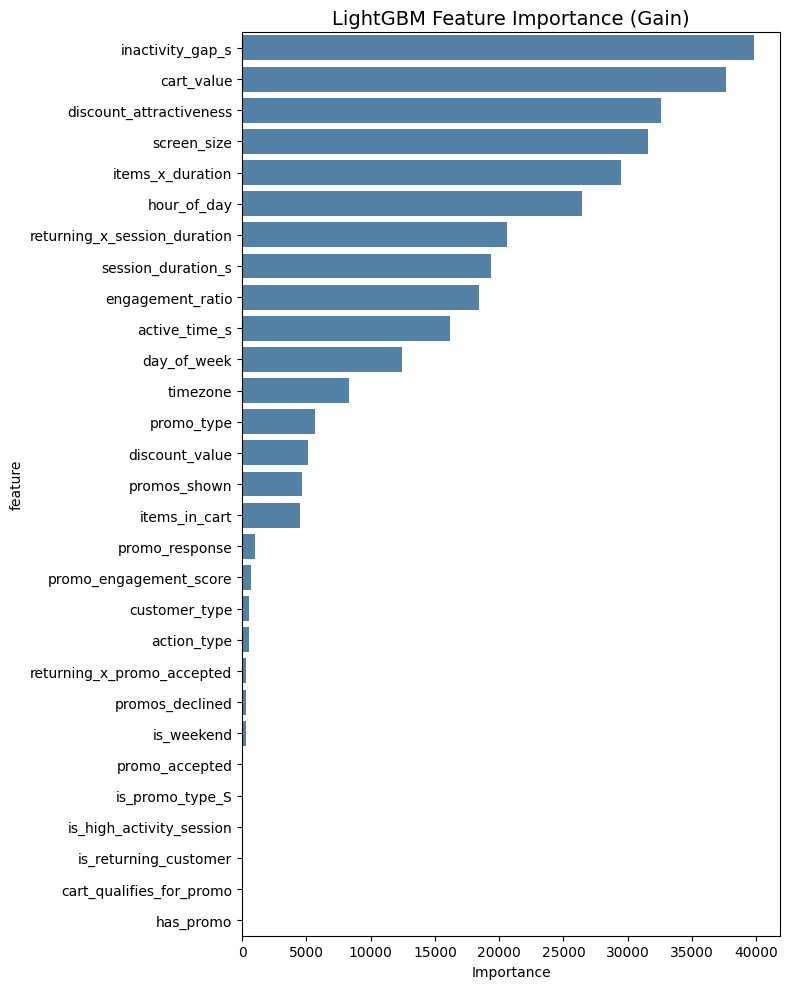


Top 10 features:
                     feature  importance
            inactivity_gap_s       39866
                  cart_value       37645
     discount_attractiveness       32626
                 screen_size       31556
            items_x_duration       29453
                 hour_of_day       26440
returning_x_session_duration       20648
          session_duration_s       19403
            engagement_ratio       18467
               active_time_s       16151


In [12]:
# Train one final LGB on full data for feature importance
final_lgb = lgb.LGBMClassifier(**best_lgb_params)
final_lgb.fit(X, y, callbacks=[lgb.log_evaluation(-1)])

importance_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': final_lgb.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(data=importance_df, x='importance', y='feature', color='steelblue', ax=ax)
ax.set_title('LightGBM Feature Importance (Gain)', fontsize=14)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'feature_importance.png'), dpi=150)
plt.show()

print('\nTop 10 features:')
print(importance_df.head(10).to_string(index=False))

## 10. Results Summary

In [13]:
print('=' * 55)
print('MODELING RESULTS SUMMARY')
print('=' * 55)
print(f'  Baseline LightGBM (default params) : {auc_lgb_base:.5f}')
print(f'  Tuned LightGBM   (Optuna 100)      : {auc_lgb:.5f}')
print(f'  Tuned XGBoost    (Optuna 100)      : {auc_xgb:.5f}')
print(f'  Tuned CatBoost   (Optuna 50)       : {auc_cb:.5f}')
print('-' * 55)
print(f'  ENSEMBLE (weighted avg)            : {ensemble_auc:.5f}')
print('=' * 55)
print(f'\nEnsemble weights:')
print(f'  LightGBM : {weights[0]:.4f}')
print(f'  XGBoost  : {weights[1]:.4f}')
print(f'  CatBoost : {weights[2]:.4f}')

MODELING RESULTS SUMMARY
  Baseline LightGBM (default params) : 0.96158
  Tuned LightGBM   (Optuna 100)      : 0.96717
  Tuned XGBoost    (Optuna 100)      : 0.97045
  Tuned CatBoost   (Optuna 50)       : 0.96883
-------------------------------------------------------
  ENSEMBLE (weighted avg)            : 0.97007

Ensemble weights:
  LightGBM : 0.3328
  XGBoost  : 0.3339
  CatBoost : 0.3333


## 11. Generate Submission

The submission file must contain exactly two columns: `id` and `order_placed` (predicted probability, not binary label).

In [14]:
submission = pd.DataFrame({
    'id'          : test['id'],
    'order_placed': test_ensemble
})

submission.to_csv(SUB_PATH, index=False)

print(f'✅ Submission saved to: {SUB_PATH}')
print(f'   Shape: {submission.shape}')
print(f'   Predicted probability range: [{submission["order_placed"].min():.4f}, {submission["order_placed"].max():.4f}]')
print(f'   Mean predicted probability : {submission["order_placed"].mean():.4f}')
print()
print('Sample rows:')
print(submission.head(10).to_string(index=False))

✅ Submission saved to: c:\Users\User\OneDrive - Lebanese American University\University\SPRING 2026\COE 546 Machine Learning\Term Project\user_prediction_app\outputs\submission.csv
   Shape: (99639, 2)
   Predicted probability range: [0.0071, 0.7662]
   Mean predicted probability : 0.0982

Sample rows:
 id  order_placed
  1      0.007300
  8      0.023997
 10      0.007510
 15      0.007296
 20      0.007444
 22      0.007326
 27      0.019813
 29      0.007422
 37      0.017101
 47      0.007315


## 12. Modeling Summary

| Step | Detail |
|---|---|
| Features | 29 total (17 original + 12 engineered) |
| Validation | 5-fold Stratified CV (3-fold inside Optuna trials) |
| Class imbalance | scale_pos_weight = 33.4 (LGB/XGB), class_weights (CatBoost) |
| Tuning | Optuna TPE — 100 trials (LGB), 100 trials (XGB), 50 trials (CatBoost) |
| Early stopping | 50 rounds patience on validation AUC |
| Ensemble | Weighted average by CV AUC score |
| Submission | Probabilities for 99,639 test sessions |

**Submit `outputs/submission.csv` to Kaggle.**

In [15]:
# ── XGBoost-only submission ────────────────────────────────────────────────
xgb_sub = pd.DataFrame({
    'id'          : test['id'],
    'order_placed': test_xgb
})

xgb_sub_path = os.path.join(OUT_DIR, 'submission_xgb_only.csv')
xgb_sub.to_csv(xgb_sub_path, index=False)

print(f'✅ XGBoost-only submission saved')
print(f'   Shape: {xgb_sub.shape}')
print(f'   Prob range: [{xgb_sub["order_placed"].min():.4f}, {xgb_sub["order_placed"].max():.4f}]')
print(f'   Mean prob : {xgb_sub["order_placed"].mean():.4f}')

✅ XGBoost-only submission saved
   Shape: (99639, 2)
   Prob range: [0.0001, 0.9953]
   Mean prob : 0.1133
